
### Filtr RC

In [5]:
import numpy as np
from scipy import signal

# Parametry filtru
R = 1000.0    # [Ohm]
C = 1e-6      # [F]
tau = R * C   # stala czasowa [s] = 1 ms
fc  = 1 / (2 * np.pi * tau)   # czestotliwosc graniczna [Hz] ≈ 159 Hz

# Transmitancja G(s) = 1 / (tau*s + 1)
sys = signal.lti([1], [tau, 1])

# Odpowiedz skokowa
t = np.linspace(0, 0.01, 1000)   # 0-10 ms
t_step, y_step = signal.step(sys, T=t)

# Weryfikacja: y(tau) powinno wynosic 1 - 1/e
idx_tau = np.argmin(np.abs(t_step - tau))
print(f"y(tau) = {y_step[idx_tau]:.4f}  (teoria: {1 - np.exp(-1):.4f})")

# Charakterystyka amplitudowa
w = np.logspace(1, 6, 1000)      # zakres 10 Hz - 1 MHz
w_resp, H = signal.freqresp(sys, w=w)
f = w_resp / (2 * np.pi)

# Punkt -3 dB
gain_dB = 20 * np.log10(np.abs(H))
idx_3dB = np.argmin(np.abs(gain_dB + 3))
print(f"Czestotliwosc graniczna (-3 dB): {f[idx_3dB]:.1f} Hz  (teoria: {fc:.1f} Hz)")

y(tau) = 0.6325  (teoria: 0.6321)
Czestotliwosc graniczna (-3 dB): 158.1 Hz  (teoria: 159.2 Hz)


### Odpowiedź skokowa

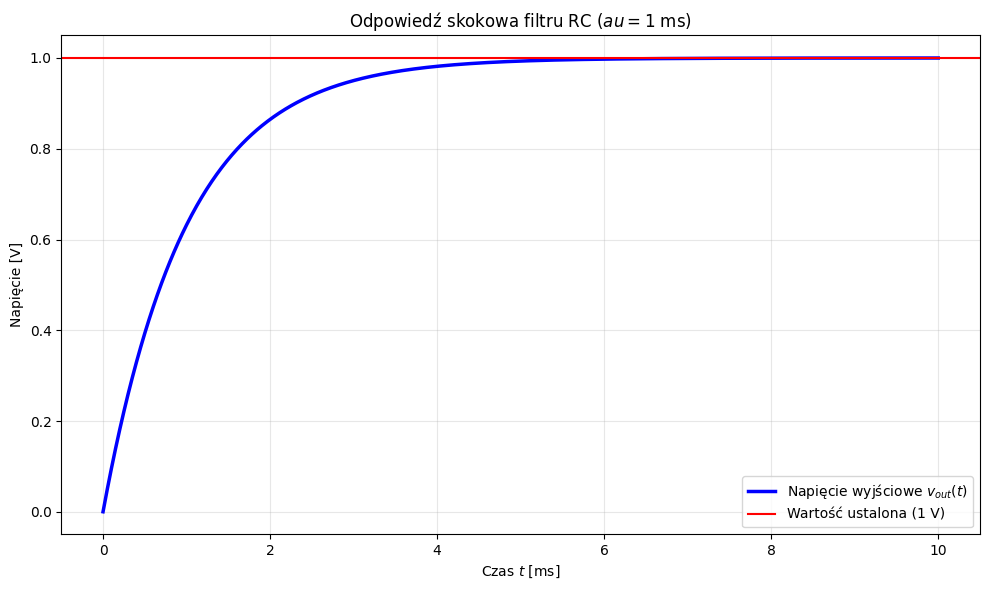

In [8]:
import matplotlib.pyplot as plt

t, y = signal.step(sys, T=t)

plt.figure(figsize=(10, 6))
plt.plot(t * 1000, y, 'b-', linewidth=2.5, label='Napięcie wyjściowe $v_{out}(t)$')
plt.axhline(1.0, color='r', linestyle='-', linewidth=1.5, label='Wartość ustalona (1 V)')
plt.xlabel('Czas $t$ [ms]')
plt.ylabel('Napięcie [V]')
plt.title('Odpowiedź skokowa filtru RC ($\tau = 1$ ms)')
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

###  Charakterystyka amplitudowa

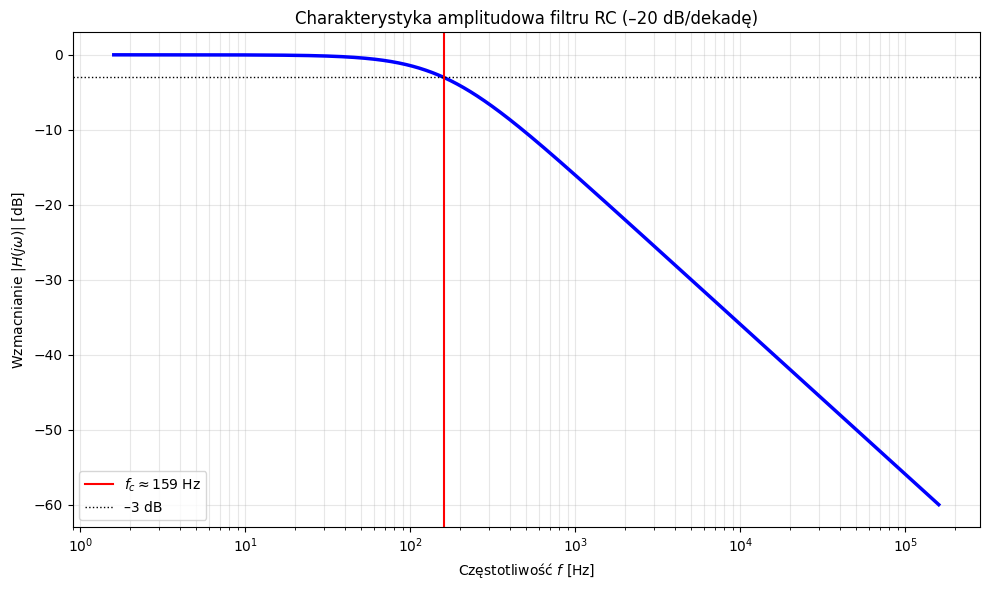

In [9]:
w, H = signal.freqresp(sys, w=np.logspace(1, 6, 1000))
f = w / (2 * np.pi)

plt.figure(figsize=(10, 6))
plt.semilogx(f, 20 * np.log10(np.abs(H)), 'b-', linewidth=2.5)
plt.axvline(fc, color='r', linestyle='-', linewidth=1.5,
            label=f'$f_c \\approx {fc:.0f}$ Hz')
plt.axhline(-3, color='k', linestyle=':', linewidth=1, label='–3 dB')
plt.xlabel('Częstotliwość $f$ [Hz]')
plt.ylabel('Wzmacnianie $|H(j\\omega)|$ [dB]')
plt.title('Charakterystyka amplitudowa filtru RC (–20 dB/dekadę)')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()